In [1]:
import numpy as np
import matplotlib.pyplot as plt
import blade_params

def plot_blade(blade: blade_params.Blade, blade_name: str):
    y = np.linspace(0, blade.y_max, 100)
    chord = [blade.get_chord(y_val) for y_val in y]
    pitch = [blade.get_blade_pitch(y_val) for y_val in y]

    # Leading edge stays on y-axis
    x_lead = np.zeros_like(y)
    z_lead = np.zeros_like(y)

    # Trailing edge determined by chord and pitch
    x_trail = chord * -np.cos(pitch)
    z_trail = chord * -np.sin(pitch)

    # Build a simple blade surface between leading and trailing edge
    X = np.vstack([x_lead, x_trail])
    Y = np.vstack([y, y])
    Z = np.vstack([z_lead, z_trail])

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Surface
    ax.plot_surface(X, Y, Z, alpha=0.8)

    # Leading and trailing edges
    ax.plot(x_lead, y, z_lead, label='Leading Edge', linewidth=2)
    ax.plot(x_trail, y, z_trail, label='Trailing Edge', linewidth=2)

    ax.set_title(f'Blade Geometry: {blade_name}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.legend()
    ax.set_xlim(-blade.y_max, 0)
    ax.set_ylim(0, blade.y_max)
    ax.set_zlim(-blade.y_max, 0)
    plt.tight_layout()
    return fig, ax


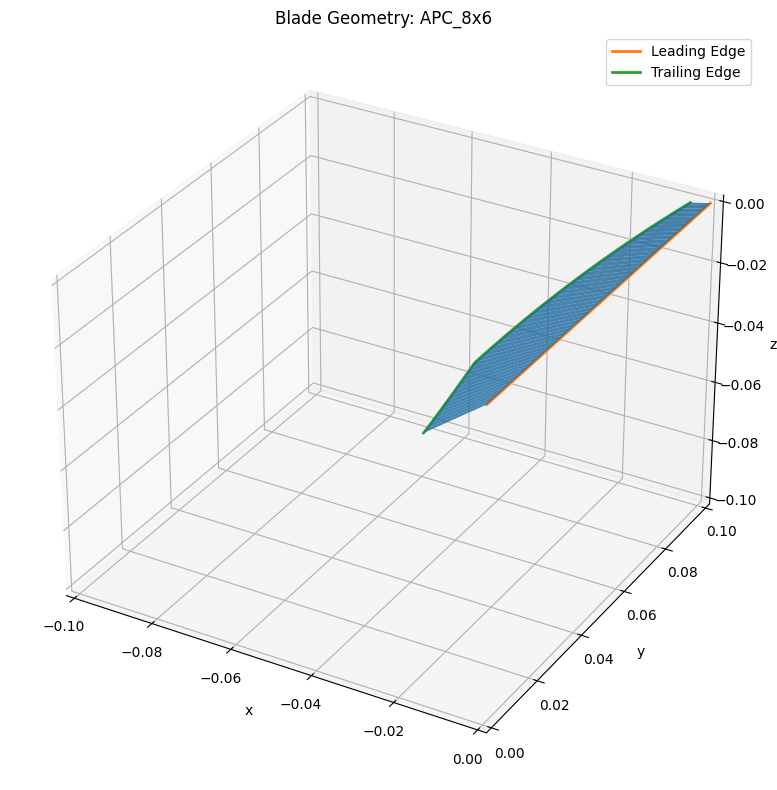

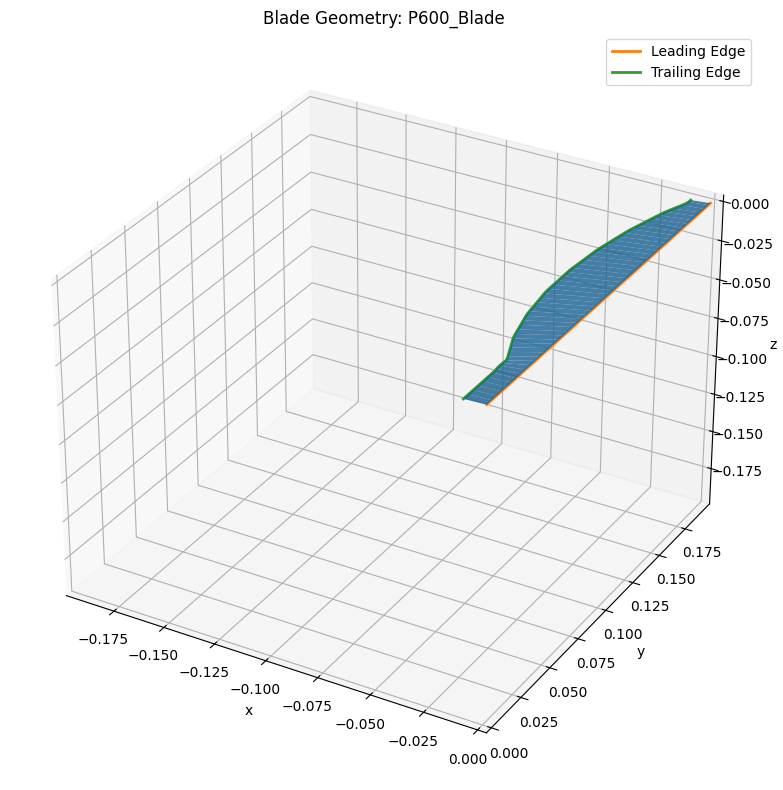

In [2]:
plot_blade(blade_params.APC_8x6(), "APC_8x6")
plot_blade(blade_params.P600_Blade(), "P600_Blade")
plt.show()
